In [1]:
import igl
import numpy as np
from src.ms import MorseSmale
from src import vis
from src import pathtools
from src import triangletools

import networkx as nx
import pandas as pd

from tqdm.notebook import tqdm
from src.timing import Timer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pyvista as pv

from src import shapes

In [3]:
f_dist = lambda p: np.linalg.norm(p, axis=-1, ord=2)
f_linear = lambda p: p[:, 1]

In [4]:
import trimesh

mesh = trimesh.load("data/halftori-bouquet-mesh-iso.ply")

vertices = mesh.vertices      
faces = mesh.faces            
values = f_dist(vertices)

print(f'vertices.shape = {vertices.shape}')
print(f'faces.shape = {faces.shape}')
print(f'values.shape = {values.shape}')


vertices.shape = (1138, 3)
faces.shape = (2280, 3)
values.shape = (1138,)


In [5]:
import pickle as pkl

with open('data/hard-goat.pkl', 'rb') as file:
#with open('data/hard-goat-cut.pkl', 'rb') as file:
    vertices, faces, values = pkl.load(file)

print(f'vertices.shape = {vertices.shape}')
print(f'faces.shape = {faces.shape}')
print(f'values.shape = {values.shape}')

vertices.shape = (2150, 3)
faces.shape = (3998, 3)
values.shape = (2150,)


In [6]:
mesh = vis.get_pv_mesh(vertices, faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, scalars=values, cmap="viridis", smooth_shading=False, show_edges=True, opacity=1.0)
pl.show()

Widget(value='<iframe src="http://localhost:38971/index.html?ui=P_0x7810431a6de0_0&reconnect=auto" class="pyvi…

 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler


In [7]:
ms = MorseSmale(faces=faces, values=values, vertices=vertices)

In [8]:
(ms.local_maxima, ms.local_minima, ms.saddles)

(array([   0,  224,  534, 1130, 1694, 2107, 2120, 2137]),
 array([  80,  196,  523, 1058, 1176, 1199, 1778, 1897, 2089]),
 array([  54,   71,  158,  449,  489,  525,  931,  977, 1003, 1148, 1270,
        1350, 1451, 1564, 1921, 2013, 2129]))

In [9]:
print(f'local_maxima: {len(ms.local_maxima)}')
print(f'local_minima: {len(ms.local_minima)}')
print(f'saddles: {len(ms.saddles)}')

local_maxima: 8
local_minima: 9
saddles: 17


In [10]:
ms.saddles

array([  54,   71,  158,  449,  489,  525,  931,  977, 1003, 1148, 1270,
       1350, 1451, 1564, 1921, 2013, 2129])

In [11]:
print(f'          ms.local_maxima  = {ms.local_maxima}\nms.values[ms.local_maxima] = {ms.values[ms.local_maxima]}')
print(f'          ms.local_minima  = {ms.local_minima}\nms.values[ms.local_minima] = {ms.values[ms.local_minima]}')
print(f'          ms.saddles  = {ms.saddles}\nms.values[ms.saddles] = {ms.values[ms.saddles]}')


          ms.local_maxima  = [   0  224  534 1130 1694 2107 2120 2137]
ms.values[ms.local_maxima] = [ 1.          0.97929624  0.99043239  0.99876966 -0.2022893   1.
  0.99996618  0.9999514 ]
          ms.local_minima  = [  80  196  523 1058 1176 1199 1778 1897 2089]
ms.values[ms.local_minima] = [-0.98801457 -1.00656034 -1.00524038 -1.00660782 -1.00590338 -1.00164579
 -1.00636823 -1.52792293 -0.69119076]
          ms.saddles  = [  54   71  158  449  489  525  931  977 1003 1148 1270 1350 1451 1564
 1921 2013 2129]
ms.values[ms.saddles] = [-0.9813481   0.59429978 -0.99989386 -0.27504044 -0.99857391  0.36964455
 -0.87721937 -0.68711423 -0.25429362 -0.99497931 -0.94130074 -0.45005335
 -0.20907633  0.87358264 -0.99923691 -0.99970176 -0.99994135]


In [12]:
ms.get_directions_queue()

deque([(54, np.int32(35)),
       (54, np.int32(55)),
       (71, np.int32(48)),
       (71, np.int32(102)),
       (158, np.int32(122)),
       (158, np.int32(195)),
       (449, np.int32(477)),
       (449, np.int32(431)),
       (489, np.int32(426)),
       (489, np.int32(524)),
       (525, np.int32(472)),
       (525, np.int32(546)),
       (931, np.int32(856)),
       (931, np.int32(1014)),
       (977, np.int32(898)),
       (977, np.int32(978)),
       (1003, np.int32(1002)),
       (1003, np.int32(1004)),
       (1148, np.int32(1069)),
       (1148, np.int32(1282)),
       (1270, np.int32(1188)),
       (1270, np.int32(1346)),
       (1350, np.int32(1274)),
       (1350, np.int32(1423)),
       (1451, np.int32(1376)),
       (1451, np.int32(1475)),
       (1564, np.int32(1593)),
       (1564, np.int32(1823)),
       (1921, np.int32(1899)),
       (1921, np.int32(2111)),
       (2013, np.int32(2086)),
       (2013, np.int32(2145)),
       (2129, np.int32(1960)),
       (2129, n

In [13]:
paths = ms.get_paths(how='increasing-decreasing')
#paths = ms.get_paths(how='decreasing-increasing')

assert len(paths) == len(ms.get_directions_queue())

Searching paths: 100%|██████████| 61/61 [00:04<00:00, 13.12it/s, Returned directions=set()]                            


In [14]:
pl = pv.Plotter(window_size=(600, 600))


pl.add_mesh(mesh, scalars=values, cmap="viridis", smooth_shading=False, show_edges=True, opacity=1.0)
pl.add_points(ms.vertices[ms.local_minima], color="lime", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[ms.local_maxima], color="red", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[ms.saddles], color="orchid", point_size=12, render_points_as_spheres=True)

for path in ms.get_paths():
    n_sides = len(pathtools.get_path_sides(path, faces))
    path_color = {1: 'orangered', 2: 'white'}[n_sides]

    path_vertices = ms.vertices[path]

    line = pv.lines_from_points(path_vertices)
    pl.add_mesh(
        line,
        color=path_color,
        line_width=6,
        render_lines_as_tubes=True,
    )


pl.show()

Widget(value='<iframe src="http://localhost:38971/index.html?ui=P_0x78104167de80_1&reconnect=auto" class="pyvi…

In [15]:
pl = pv.Plotter(window_size=(600, 600))

pl.add_mesh(mesh, scalars=values, cmap="viridis", smooth_shading=False, show_edges=True, opacity=1.0)
pl.add_points(ms.vertices[ms.local_minima], color="lime", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[ms.local_maxima], color="red", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[ms.saddles], color="orchid", point_size=12, render_points_as_spheres=True)

for path_vertices in tqdm(ms.iterate_paths_close_geodesics(), total=ms.n_paths):
    line = pv.lines_from_points(path_vertices)
    pl.add_mesh(
        line,
        color="white",
        line_width=6,
        render_lines_as_tubes=True,
    )


pl.show()

  0%|          | 0/61 [00:00<?, ?it/s]

Widget(value='<iframe src="http://localhost:38971/index.html?ui=P_0x781019ae33e0_2&reconnect=auto" class="pyvi…

__Bug:__ The fifth path from the saddle.

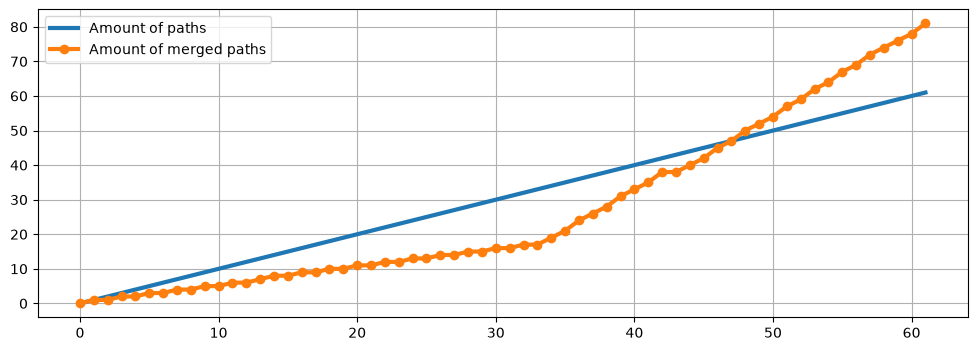

In [16]:
merged_paths_amounts = [len(pathtools.merge_paths_at_nodes([paths[j] for j in range(i)], ms.saddles)) for i in range(len(paths) + 1)]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(paths) + 1), np.arange(len(paths) + 1), linewidth=3, label='Amount of paths')
plt.plot(np.arange(len(paths) + 1), merged_paths_amounts, linewidth=3, marker='o', label='Amount of merged paths')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
paths_after_cancellation = ms.get_paths_after_cancellations()

In [18]:
len(paths), ms.n_paths

(61, 61)

In [19]:
with Timer():
    quadrangle_labels = ms.get_quadrangle_labels()

Process done in 0.3875 seconds.


In [20]:
n_labels, labels = ms.get_labels_separated_by_paths(ms.get_paths_after_cancellations())
labels

array([ 0,  1,  1, ..., 18, 14, 18], shape=(3998,), dtype=int32)

In [21]:
pl = pv.Plotter(window_size=(600, 600))


scalars = labels
scalars = quadrangle_labels

cmap = 'rainbow'
if np.unique(scalars).size <= 20:
    scmap = 'tab20'
if np.unique(scalars).size <= 10:
    scmap = 'tab10'

mesh = vis.get_pv_mesh(ms.vertices, ms.faces)
pl.add_mesh(mesh, scalars=scalars, categories=True, cmap="tab20", smooth_shading=False, show_edges=True, opacity=1.0)
pl.add_points(ms.vertices[np.intersect1d(ms.local_minima, [path[-1] for path in paths_after_cancellation])], color="lime", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[np.intersect1d(ms.local_maxima, [path[-1] for path in paths_after_cancellation])], color="red", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[np.intersect1d(ms.saddles, [path[0] for path in paths_after_cancellation])], color="orchid", point_size=12, render_points_as_spheres=True)


for path in paths_after_cancellation:
    path_vertices = ms.vertices[path]
    line = pv.lines_from_points(path_vertices)
    pl.add_mesh(line, color='black', line_width=4, render_lines_as_tubes=True)

for path in paths_after_cancellation:
    path_vertices = pathtools.get_path_close_geodesic(path, ms.faces, ms.vertices)
    line = pv.lines_from_points(path_vertices)
    pl.add_mesh(line, color='white', line_width=4, render_lines_as_tubes=True)
    

pl.show()

Widget(value='<iframe src="http://localhost:38971/index.html?ui=P_0x7810423643e0_3&reconnect=auto" class="pyvi…